In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [2]:
data= pd.read_csv("data/users.csv")

In [3]:

df=pd.get_dummies(data, columns=['Gender'] ,drop_first=True).astype(int)
df.head()

,User ID,Age,EstimatedSalary,Purchased,Gender_Male
0,15624510,12,19000,0,1
1,15810944,11,20000,0,1
2,15668575,1,43000,0,0
3,15603246,27,57000,0,0
4,15804002,10,76000,0,1


In [5]:
X=df[["Age","EstimatedSalary","Gender_Male"]]
X

,Age,EstimatedSalary,Gender_Male
0,12,19000,1
1,11,20000,1
2,1,43000,0
3,27,57000,0
4,10,76000,1
...,...,...,...
94,45,83000,0
95,35,44000,0
96,4,25000,0
97,5,123000,1


In [6]:
y=df[["Purchased"]]

In [7]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X= scaler.fit_transform(X)
X

array([[ 0.08509661, -1.16400359,  0.98994949],
       [ 0.0177001 , -1.13386068,  0.98994949],
       [-0.65626507, -0.44057369, -1.01015254],
       [ 1.09604436, -0.01857291, -1.01015254],
       [-0.04969642,  0.55414244,  0.98994949],
       [-0.65626507,  0.01157001,  0.98994949],
       [-0.65626507,  0.79528574, -1.01015254],
       [-0.25188597,  2.78471799, -1.01015254],
       [-0.386679  , -0.74200281,  0.98994949],
       [-0.18448945,  0.2225704 , -1.01015254],
       [-0.11709294,  0.67471409, -1.01015254],
       [-0.45407552, -0.16928747, -1.01015254],
       [-0.65626507,  0.85557157,  0.98994949],
       [-0.386679  , -1.19414651,  0.98994949],
       [-0.65626507,  0.73499991,  0.98994949],
       [-0.58886855,  0.67471409,  0.98994949],
       [-0.45407552, -0.98314612,  0.98994949],
       [-0.31928249, -0.9530032 ,  0.98994949],
       [-0.45407552, -0.89271738,  0.98994949],
       [-0.65626507, -0.86257447, -1.01015254],
       [-0.52147204, -1.07357485,  0.989

In [8]:
X_train,X_test,y_train,y_test= train_test_split(X,y, test_size=0.2,random_state=42)

In [9]:
model=DecisionTreeClassifier(max_depth=10,random_state=42)

In [10]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [11]:
ypred=model.predict(X_test)


In [12]:
accuracy_score(y_test, ypred)

0.8

In [13]:
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           0       0.82      0.93      0.88        15
           1       0.67      0.40      0.50         5

    accuracy                           0.80        20
   macro avg       0.75      0.67      0.69        20
weighted avg       0.78      0.80      0.78        20



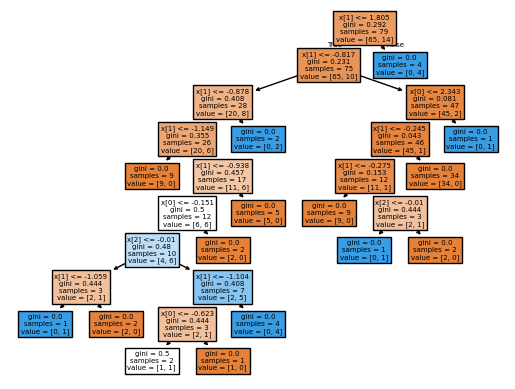

In [14]:
from sklearn.tree import plot_tree
plt.Figure(figsize=(15,10))
plot_tree(model, filled=True)
plt.show()

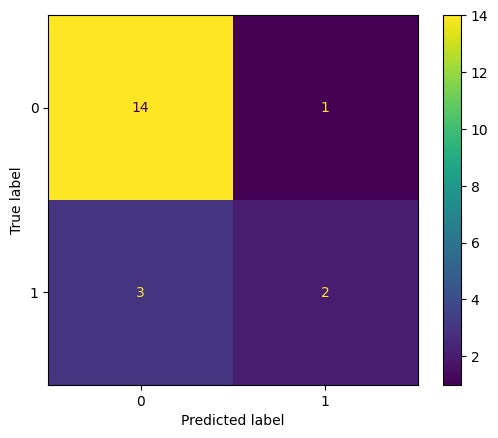

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, ypred)

In [22]:
from sklearn.datasets import load_iris
iris= load_iris()
df= pd.DataFrame(iris.data, columns=iris.feature_names)
df['species']= iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [27]:
X=df.iloc[:,0:4].values
X
y=df.iloc[:,-1].values
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [28]:
from sklearn.naive_bayes import GaussianNB

In [30]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42)

In [31]:
model=GaussianNB()
model.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [33]:
ypred=model.predict(X_test)

In [34]:
accuracy_score(y_test, ypred)

1.0

In [36]:
classification_report(y_test,ypred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        10\n           1       1.00      1.00      1.00         9\n           2       1.00      1.00      1.00        11\n\n    accuracy                           1.00        30\n   macro avg       1.00      1.00      1.00        30\nweighted avg       1.00      1.00      1.00        30\n'

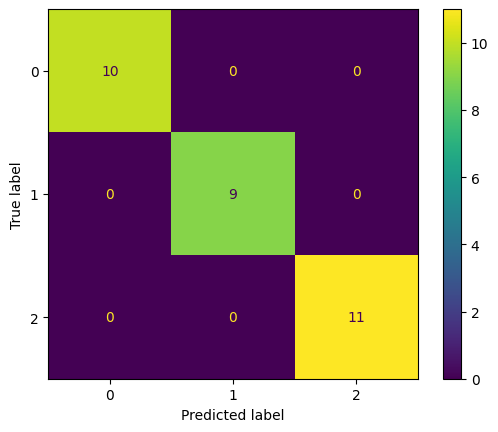

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,ypred)

In [40]:
data= pd.read_csv("spambase.csv")
data.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_req_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.64,0.00,0.00,0.00,0.32,0.00,1.29,1.93,0.00,0.96,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.0,0.06,0.06,0.0,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [44]:
X=data.iloc[:,:-1].values
y=data.iloc[:,-1].values

In [48]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()#n_estimators=10, min_samples_split=20,min_impurity_decrease=0.02
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
model.predict(X_test)

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [52]:
from sklearn.ensemble import AdaBoostClassifier
model=AdaBoostClassifier()
model.fit(X_train, y_train)
model.predict(X_test)

array([1, 0, 2, 1, 1, 0, 1, 2, 2, 1, 1, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])